## K means clustering Algorithms implmentation

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

In [2]:
# Create dummy data

X, y = make_blobs(n_samples = 1000, centers = 3, n_features = 2, random_state = 23)

In [3]:
X

array([[-5.37039106,  3.47555168],
       [ 5.84161203, -3.98182959],
       [ 1.76127766,  9.39696306],
       ...,
       [ 6.14147823, -5.75491603],
       [-5.45330839,  1.75599573],
       [-0.21966953,  8.72922042]], shape=(1000, 2))

In [4]:
y

array([2, 1, 0, 2, 1, 0, 2, 1, 2, 0, 0, 0, 2, 0, 1, 2, 2, 2, 1, 1, 0, 1,
       2, 2, 0, 0, 1, 2, 0, 0, 0, 2, 1, 2, 1, 0, 1, 2, 2, 1, 0, 1, 1, 2,
       2, 1, 0, 2, 1, 1, 2, 2, 1, 2, 0, 2, 0, 2, 2, 2, 1, 0, 2, 2, 2, 2,
       2, 2, 0, 2, 2, 0, 0, 1, 1, 2, 0, 0, 1, 1, 0, 2, 1, 2, 2, 0, 1, 2,
       1, 2, 0, 1, 0, 0, 2, 0, 2, 1, 2, 2, 0, 2, 1, 2, 2, 2, 2, 0, 1, 1,
       0, 2, 2, 2, 2, 2, 2, 1, 2, 0, 0, 0, 1, 1, 1, 1, 0, 0, 2, 0, 2, 1,
       0, 0, 2, 1, 1, 2, 1, 2, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 2, 0, 0,
       1, 1, 1, 1, 2, 1, 2, 1, 0, 2, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 2,
       0, 0, 2, 1, 1, 2, 0, 1, 2, 1, 0, 1, 1, 1, 1, 1, 1, 2, 2, 1, 2, 0,
       2, 2, 2, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0, 1, 0, 2, 0, 1, 1, 0, 0, 1,
       1, 2, 0, 2, 0, 1, 2, 2, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 2, 1, 2, 1, 0, 2, 0, 0, 2, 2, 0, 1, 0, 1, 1, 2, 1, 0, 0,
       1, 0, 0, 0, 1, 2, 0, 2, 0, 1, 0, 1, 2, 2, 2, 0, 1, 0, 1, 2, 2, 0,
       0, 0, 0, 0, 0, 2, 1, 1, 2, 0, 2, 2, 1, 1, 1,

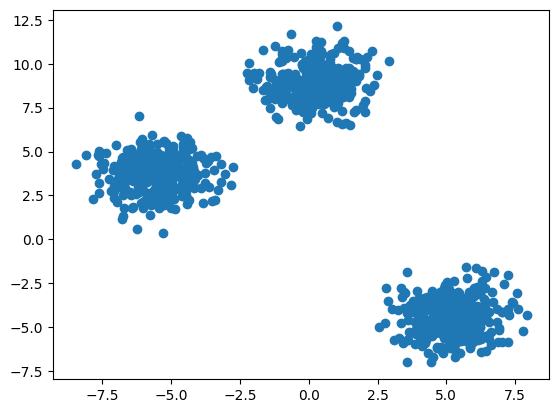

In [7]:
# plot the data to understand
plt.scatter(X[:,0], X[:,1])

In [8]:
from sklearn.model_selection import train_test_split

In [10]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.33, random_state=42)

In [14]:
# import KMeans function
from sklearn.cluster import KMeans

In [15]:
KMeans

sklearn.cluster._kmeans.KMeans

In [16]:
## Elbow method to select K value
wcss =[]
for k in range(1, 11):
    kmeans=KMeans(n_clusters = k, init='k-means++', n_init=1)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [17]:
wcss

[34827.57682552022,
 7935.4372861454185,
 1319.2730531585607,
 1183.3036668391449,
 992.0708509383512,
 854.1166400886464,
 768.0052398679996,
 677.0522601110999,
 603.8286864811666,
 545.2012078158785]

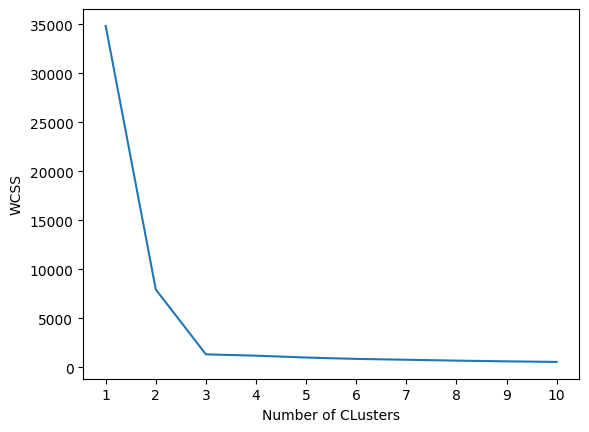

In [19]:
# Plot elbow curve
plt.plot(range(1, 11),wcss)
plt.xticks(range(1, 11))
plt.xlabel("Number of CLusters")
plt.ylabel("WCSS")
plt.show()

In [20]:
kmeans = KMeans(n_clusters =3, init="k-means++")

In [21]:
y_labels = kmeans.fit_predict(X_train)

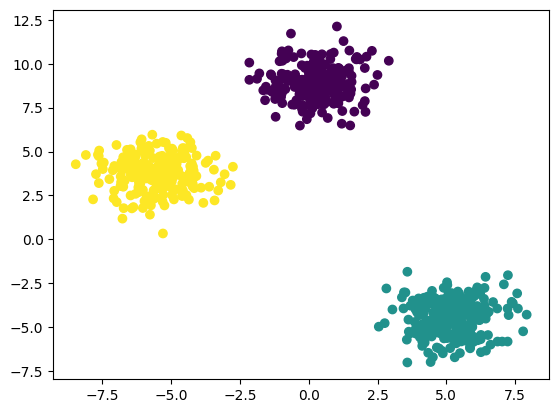

In [22]:
plt.scatter(X_train[:,0], X_train[:,1],c=y_labels)

In [25]:
# Silhoutte score : its kind of accuracy that explains how much your cluster is better...
from sklearn.metrics import silhouette_score

In [26]:
silhouette_coefficients =[]
for k in range(2,11):
    kmeans = KMeans(n_clusters =k, init="k-means++")
    kmeans.fit(X_train)
    score=silhouette_score(X_train, kmeans.labels_)
    silhouette_coefficients.append(score)

In [27]:
silhouette_coefficients

[0.7281443868598331,
 0.8071181203797672,
 0.6357733426488265,
 0.6547049554421754,
 0.6259039898750166,
 0.34700167512592045,
 0.33417251279518434,
 0.32804404880335175,
 0.3286498561103146]

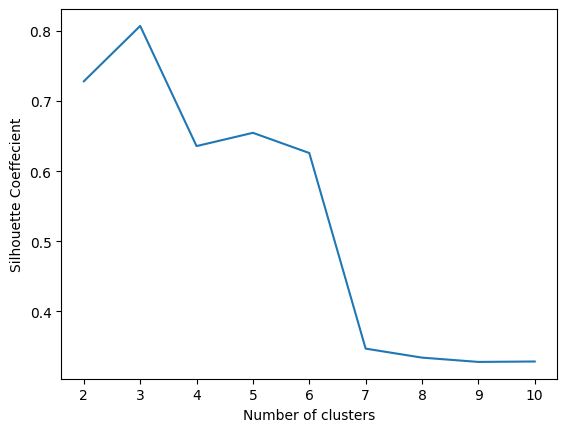

In [29]:
# plotting silhouette score
plt.plot(range(2,11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Coeffecient")
plt.show()